# CF and UGRID Standards
## xarray-cf and xugrid packages

**Duration: ~30 minutes**

This notebook uses real SHYFEM ocean model output for **Antsiranana Bay, Madagascar** to demonstrate two important metadata conventions and the Python packages that leverage them:

| Convention | Scope | Python Package |
|---|---|---|
| [CF Conventions](https://cfconventions.org/) | Variable semantics (names, units, axes) | [`cf_xarray`](https://cf-xarray.readthedocs.io/) |
| [UGRID Conventions](https://ugrid-conventions.github.io/ugrid-conventions/) | Unstructured mesh topology | [`xugrid`](https://deltares.github.io/xugrid/) |

The SHYFEM model runs on an unstructured triangular mesh — a good real-world example of why both conventions matter.

In [1]:
import os
import numpy as np
import xarray as xr
import cf_xarray
import hvplot.xarray
import holoviews as hv
from dotenv import load_dotenv
import fsspec

_ = load_dotenv(f'{os.environ["HOME"]}/dotenv/protocoast.env', override=True)

endpoint = os.environ['ENDPOINT_URL']
so = dict(anon=False, endpoint_url=endpoint)

---
## Part 1: CF Conventions and cf_xarray (≈15 min)

### 1.1 What are CF Conventions?

The [Climate and Forecast (CF) Metadata Conventions](https://cfconventions.org/) standardize how variables, coordinates, and units are described in NetCDF and Zarr files. Without them, you'd need to know that one model uses `lon_rho`, another uses `nav_lon`, another uses `x` — all for the same thing.

Key attributes:

| Attribute | Purpose | Example |
|---|---|---|
| `standard_name` | Canonical identity | `"sea_water_temperature"` |
| `units` | UDUNITS-compatible | `"degC"`, `"m s-1"`, `"days since 1970-01-01"` |
| `axis` | Coordinate type | `"X"`, `"Y"`, `"Z"`, `"T"` |
| `positive` | Vertical direction | `"up"` or `"down"` |
| `coordinates` | Auxiliary coordinates | `"lon lat depth"` |
| `cell_methods` | Statistical operation | `"time: mean"` |

The global `Conventions` attribute declares compliance, e.g. `"CF-1.8"`.

### 1.2 Open the Antsiranana SHYFEM dataset

Two NetCDF files on S3-compatible object storage (EGI/rustfs):
- **surf.nos.nc4** — salinity, temperature (node × level × time)
- **surf.ous.nc4** — water_level, u_velocity, v_velocity (node × time)

In [2]:
fs = fsspec.filesystem('s3', anon=False, endpoint_url=os.environ['ENDPOINT_URL'])
base = 's3://protocoast-data/full_dataset/shyfem/antsiranana'

ds_nos = xr.open_dataset(fs.open(f'{base}/surf.nos.nc4'))
ds_ous = xr.open_dataset(fs.open(f'{base}/surf.ous.nc4'))
# Merge into a single dataset
ds = xr.merge([ds_nos, ds_ous], compat='override')
ds

<xarray.Dataset> Size: 1GB
Dimensions:        (node: 7817, element: 14602, vertex: 3, time: 145, level: 36)
Coordinates:
  * level          (level) float64 288B 2.0 4.0 6.0 8.0 ... 700.0 800.0 900.0
  * time           (time) datetime64[ns] 1kB 2021-03-31 ... 2021-04-06
Dimensions without coordinates: node, element, vertex
Data variables:
    longitude      (node) float64 63kB ...
    latitude       (node) float64 63kB ...
    total_depth    (node) float64 63kB ...
    element_index  (element, vertex) int32 175kB ...
    topology       int32 4B ...
    salinity       (time, node, level) float64 326MB ...
    temperature    (time, node, level) float64 326MB ...
    water_level    (time, node) float64 9MB ...
    u_velocity     (time, node, level) float64 326MB ...
    v_velocity     (time, node, level) float64 326MB ...
Attributes:
    Conventions:  CF-1.4
    title:        SURF
    history:      created on 2026-02-27 23:14:14 MET
    institution:  ISMAR-CNR, Venice, Italy
    source:       Model data produced by SHYFEM at ISMAR-CNR
    references:   Model info: http://www.ismar.cnr.it/shyfem
    contact:      email: georg.umgiesser@ismar.cnr.it
    comment:      Data restriction: for academic research use only

### 1.3 Inspect the CF metadata

In [3]:
# Global attributes
ds.attrs

{'Conventions': 'CF-1.4',
 'title': 'SURF',
 'history': 'created on 2026-02-27 23:14:14 MET',
 'institution': 'ISMAR-CNR, Venice, Italy',
 'source': 'Model data produced by SHYFEM at ISMAR-CNR',
 'references': 'Model info: http://www.ismar.cnr.it/shyfem',
 'contact': 'email: georg.umgiesser@ismar.cnr.it',
 'comment': 'Data restriction: for academic research use only'}

In [4]:
# Variable-level CF attributes
for vname in list(ds.coords) + list(ds.data_vars):
    attrs = ds[vname].attrs
    sn = attrs.get('standard_name', '')
    units = attrs.get('units', '')
    axis = attrs.get('axis', '')
    if sn or axis:
        print(f"{vname:20s}  standard_name={sn!r:45s}  units={units!r:12s}  axis={axis!r}")

level                 standard_name='depth'                                        units='m'           axis='Z'
time                  standard_name='time'                                         units=''            axis='T'
longitude             standard_name='longitude'                                    units='degrees_east'  axis=''
latitude              standard_name='latitude'                                     units='degrees_north'  axis=''
total_depth           standard_name='sea_floor_depth_below_sea_surface'            units='m'           axis=''
salinity              standard_name='sea_water_salinity'                           units='1e-3'        axis=''
temperature           standard_name='sea_water_temperature'                        units='degC'        axis=''
water_level           standard_name='water_surface_height_above_reference_datum'   units='m'           axis=''
u_velocity            standard_name='eastward_sea_water_velocity'                  units='m s-1'       ax

### 1.4 The `.cf` accessor from cf_xarray

Importing `cf_xarray` attaches a `.cf` accessor to every xarray object.  
It reads the CF attributes and lets you access coordinates **by role** rather than by name.

In [5]:
# Summary of what cf_xarray detects
ds.cf.describe()

Coordinates:
             CF Axes: * Z: ['level']
                      * T: ['time']
                        X, Y: n/a

      CF Coordinates: * vertical: ['level']
                      * time: ['time']
                        longitude, latitude: n/a

       Cell Measures:   area, volume: n/a

      Standard Names: * depth: ['level']
                      * time: ['time']

              Bounds:   n/a

       Grid Mappings:   n/a

Data Variables:
       Cell Measures:   area, volume: n/a

      Standard Names:   eastward_sea_water_velocity: ['u_velocity']
                        latitude: ['latitude']
                        longitude: ['longitude']
                        northward_sea_water_velocity: ['v_velocity']
                        sea_floor_depth_below_sea_surface: ['total_depth']
                        sea_water_salinity: ['salinity']
                        sea_water_temperature: ['temperature']
                        water_surface_height_above_reference_datum: ['water_l

/tmp/ipykernel_554/2031814547.py:2: DeprecationWarning: 'obj.cf.describe()' will be removed in a future version. Use instead 'repr(obj.cf)' or 'obj.cf' in a Jupyter environment.
  ds.cf.describe()


In [6]:
# Access coordinates by CF role — works regardless of the variable name
lon = ds.cf['longitude']
lat = ds.cf['latitude']
t   = ds.cf['time']
z   = ds.cf['vertical']

print(f"longitude → '{lon.name}'")
print(f"latitude  → '{lat.name}'")
print(f"time      → '{t.name}'")
print(f"vertical  → '{z.name}'")

longitude → 'longitude'
latitude  → 'latitude'
time      → 'time'
vertical  → 'level'


### 1.5 Access data variables by `standard_name`

In [7]:
# Access variables by standard_name — model-agnostic
sst = ds.cf['sea_water_temperature']
sal = ds.cf['sea_water_salinity']
wl  = ds.cf['water_surface_height_above_reference_datum']

print(f"temperature → '{sst.name}', dims={sst.dims}")
print(f"salinity    → '{sal.name}', dims={sal.dims}")
print(f"water_level → '{wl.name}',  dims={wl.dims}")

temperature → 'temperature', dims=('time', 'node', 'level')
salinity    → 'salinity', dims=('time', 'node', 'level')
water_level → 'water_level',  dims=('time', 'node')


### 1.6 Selection with `cf.sel()` and `cf.isel()`

Use CF axis keys (`T`, `Z`, `X`, `Y`) in place of coordinate variable names.

In [8]:
# Select surface (first level) at last time step
# Using CF axis names — no need to know the variable is called 'level' or 'time'
temp_surf = ds['temperature'].cf.isel(Z=0, T=-1).load()
print(f"shape: {temp_surf.shape}, time: {temp_surf.cf['time'].values}")

shape: (7817,), time: 2021-04-06T00:00:00.000000000


In [9]:
# Select a specific depth using CF axis Z — value in meters
temp_10m = ds['temperature'].cf.sel(Z=10, method='nearest').cf.isel(T=0).load()
print(f"Nearest depth level: {temp_10m.cf['vertical'].values:.0f} m")

Nearest depth level: 10 m


### 1.7 Quick map of surface temperature

Even without a structured grid, we can scatter-plot node values by their lon/lat coordinates.

In [10]:
import pandas as pd
import holoviews as hv
import geoviews as gv
import holoviews.operation.datashader as hd

hd.datashade.precompute = True

# Build a DataFrame of lon, lat, temperature at surface/last time
temp_surf = ds['temperature'].cf.isel(Z=0, T=-1).load()

df = pd.DataFrame({
    'lon': ds.cf['longitude'].values,
    'lat': ds.cf['latitude'].values,
    'temperature': temp_surf.values
})

points = gv.operation.project_points(gv.Points(df, kdims=['lon','lat'], vdims=['temperature']))
tiles  = gv.tile_sources.OSM

tiles * hd.rasterize(points).opts(
    cmap='plasma', colorbar=True, width=600, height=450,
    title='Antsiranana Bay — Surface Temperature (°C)'
)

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [lon,lat]   (Count)

---
## Part 2: UGRID Conventions and xugrid (≈15 min)

### 2.1 What are UGRID Conventions?

[UGRID](https://ugrid-conventions.github.io/ugrid-conventions/) extends CF to describe **unstructured meshes** — grids where cells are not arranged in a regular lat/lon matrix.

**Why unstructured grids?**

| Structured Grid | Unstructured Grid |
|---|---|
| Regular lat/lon or curvilinear | Triangles, quadrilaterals, polygons |
| Easy to index `[i, j]` | Requires topology connectivity |
| Wastes cells on land | Concentrates resolution where needed |
| ROMS, MOM, NEMO | FVCOM, SCHISM, **SHYFEM**, Delft3D FM |

**UGRID topology elements:**
```
node  — the points (vertices) of the mesh
edge  — line segments connecting two nodes  
face  — polygonal cells (triangles, quads, ...)
```

A **mesh topology variable** (scalar with `cf_role: mesh_topology`) declares the mesh and references the connectivity arrays.

### 2.2 Does the SHYFEM dataset follow UGRID?

The Antsiranana dataset has CF-1.4 attributes and a `topology` variable, but let's check if it's fully UGRID-compliant:

In [11]:
print("'topology' variable attributes:")
for k, v in ds['topology'].attrs.items():
    print(f"  {k}: {v}")

print("\n'element_index' variable attributes:")
for k, v in ds['element_index'].attrs.items():
    print(f"  {k}: {v}")

'topology' variable attributes:
  units: 1
  long_name: topology data of 2D unstructured mesh
  dimensionality: 2

'element_index' variable attributes:
  units: 1
  long_name: element index of nodes
  description: maps every element to its three vertices


**The topology variable is missing the UGRID-required attributes:**
- `cf_role: mesh_topology` — tells tools this is a UGRID mesh variable
- `face_node_connectivity: element_index` — points to the connectivity array
- `node_coordinates: longitude latitude` — points to the node coordinate arrays

This is common for older CF-1.4 files — the mesh information is present but not yet labeled as UGRID. We can add these attributes to make the file xugrid-compatible.

### 2.3 Add UGRID attributes and open with xugrid

In [12]:
import xugrid as xu

# Annotate the dataset with UGRID-required attributes
ds_ugrid = ds.copy()

# 1. The topology/mesh variable needs cf_role and pointers to coordinates/connectivity
ds_ugrid['topology'].attrs.update({
    'cf_role': 'mesh_topology',
    'topology_dimension': 2,
    'node_coordinates': 'longitude latitude',
    'face_node_connectivity': 'element_index',
})

# 2. The face-node connectivity array needs cf_role and start_index
ds_ugrid['element_index'].attrs.update({
    'cf_role': 'face_node_connectivity',
    'start_index': 1,        # SHYFEM uses 1-based node indices
})

# 3. Node coordinate variables need standard_name
ds_ugrid['longitude'].attrs['standard_name'] = 'longitude'
ds_ugrid['latitude'].attrs['standard_name'] = 'latitude'

# Promote lon/lat to coordinates — keep topology in data_vars so xugrid can detect it
ds_ugrid = ds_ugrid.set_coords(['longitude', 'latitude', 'total_depth'])

print(ds_ugrid)

<xarray.Dataset> Size: 1GB
Dimensions:        (node: 7817, element: 14602, vertex: 3, time: 145, level: 36)
Coordinates:
    longitude      (node) float64 63kB ...
    latitude       (node) float64 63kB ...
    total_depth    (node) float64 63kB ...
  * level          (level) float64 288B 2.0 4.0 6.0 8.0 ... 700.0 800.0 900.0
  * time           (time) datetime64[ns] 1kB 2021-03-31 ... 2021-04-06
Dimensions without coordinates: node, element, vertex
Data variables:
    element_index  (element, vertex) int32 175kB ...
    topology       int32 4B ...
    salinity       (time, node, level) float64 326MB ...
    temperature    (time, node, level) float64 326MB ...
    water_level    (time, node) float64 9MB ...
    u_velocity     (time, node, level) float64 326MB ...
    v_velocity     (time, node, level) float64 326MB ...
Attributes:
    Conventions:  CF-1.4
    title:        SURF
    history:      created on 2026-02-27 23:14:14 MET
    institution:  ISMAR-CNR, Venice, Italy
    source:   

In [14]:
ds_ugrid

<xarray.Dataset> Size: 1GB
Dimensions:        (node: 7817, element: 14602, vertex: 3, time: 145, level: 36)
Coordinates:
    longitude      (node) float64 63kB ...
    latitude       (node) float64 63kB ...
    total_depth    (node) float64 63kB ...
  * level          (level) float64 288B 2.0 4.0 6.0 8.0 ... 700.0 800.0 900.0
  * time           (time) datetime64[ns] 1kB 2021-03-31 ... 2021-04-06
Dimensions without coordinates: node, element, vertex
Data variables:
    element_index  (element, vertex) int32 175kB 9 1 10 1 ... 7817 7815 7814
    topology       int32 4B ...
    salinity       (time, node, level) float64 326MB ...
    temperature    (time, node, level) float64 326MB ...
    water_level    (time, node) float64 9MB ...
    u_velocity     (time, node, level) float64 326MB ...
    v_velocity     (time, node, level) float64 326MB ...
Attributes:
    Conventions:  CF-1.4
    title:        SURF
    history:      created on 2026-02-27 23:14:14 MET
    institution:  ISMAR-CNR, Venice, Italy
    source:       Model data produced by SHYFEM at ISMAR-CNR
    references:   Model info: http://www.ismar.cnr.it/shyfem
    contact:      email: georg.umgiesser@ismar.cnr.it
    comment:      Data restriction: for academic research use only

In [13]:
# Now open as a UgridDataset — xugrid detects the mesh_topology variable automatically
uds = xu.UgridDataset(ds_ugrid)
uds

<xarray.Dataset> Size: 1GB
Dimensions:      (node: 7817, time: 145, level: 36)
Coordinates:
    longitude    (node) float64 63kB ...
    latitude     (node) float64 63kB ...
    total_depth  (node) float64 63kB ...
  * level        (level) float64 288B 2.0 4.0 6.0 8.0 ... 700.0 800.0 900.0
  * time         (time) datetime64[ns] 1kB 2021-03-31 ... 2021-04-06
  * node         (node) int64 63kB 0 1 2 3 4 5 ... 7811 7812 7813 7814 7815 7816
Data variables:
    salinity     (time, node, level) float64 326MB ...
    temperature  (time, node, level) float64 326MB ...
    water_level  (time, node) float64 9MB ...
    u_velocity   (time, node, level) float64 326MB ...
    v_velocity   (time, node, level) float64 326MB ...
Attributes:
    Conventions:  CF-1.4
    title:        SURF
    history:      created on 2026-02-27 23:14:14 MET
    institution:  ISMAR-CNR, Venice, Italy
    source:       Model data produced by SHYFEM at ISMAR-CNR
    references:   Model info: http://www.ismar.cnr.it/shyfem
    contact:      email: georg.umgiesser@ismar.cnr.it
    comment:      Data restriction: for academic research use only

### 2.4 Inspect the mesh topology

* We'll need uds for plotting and stuff, since it is a wrapper around xarray that sorta knows how to deal with and handle unstructured mesh for plotting and stuff!

In [18]:
# %matplotlib notebook
%matplotlib inline

Mesh type:     Ugrid2d
Nodes:         7,817
Faces (tris):  14,602
Edges:         22,436


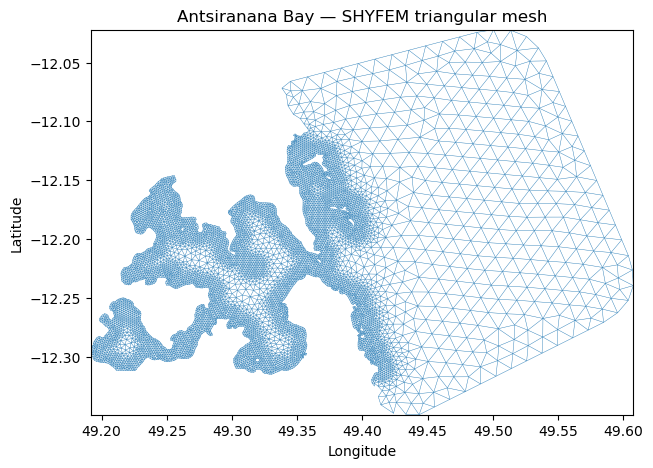

In [19]:
import matplotlib.pyplot as plt

grid = uds.ugrid.grid
print(f"Mesh type:     {type(grid).__name__}")
print(f"Nodes:         {grid.n_node:,}")
print(f"Faces (tris):  {grid.n_face:,}")
print(f"Edges:         {grid.n_edge:,}")

fig, ax = plt.subplots(figsize=(7, 5))
grid.plot(ax=ax, linewidth=0.3)
ax.set_title('Antsiranana Bay — SHYFEM triangular mesh')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

### 2.5 Plot on the native unstructured mesh

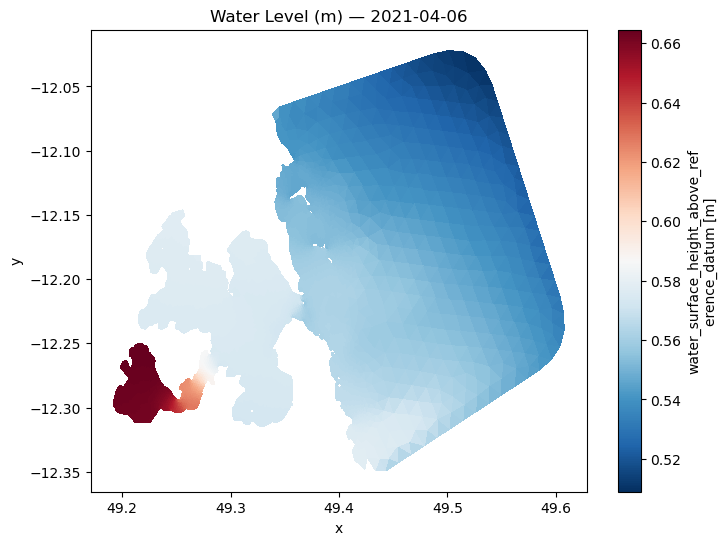

In [20]:
# Water level at last time step — native triangular mesh, no regridding
wl_t = uds['water_level'].isel(time=-1).load()

wl_t.ugrid.plot(cmap='RdBu_r', figsize=(8, 6))
plt.title(f'Water Level (m) — {str(uds.time.values[-1])[:10]}')
plt.show()

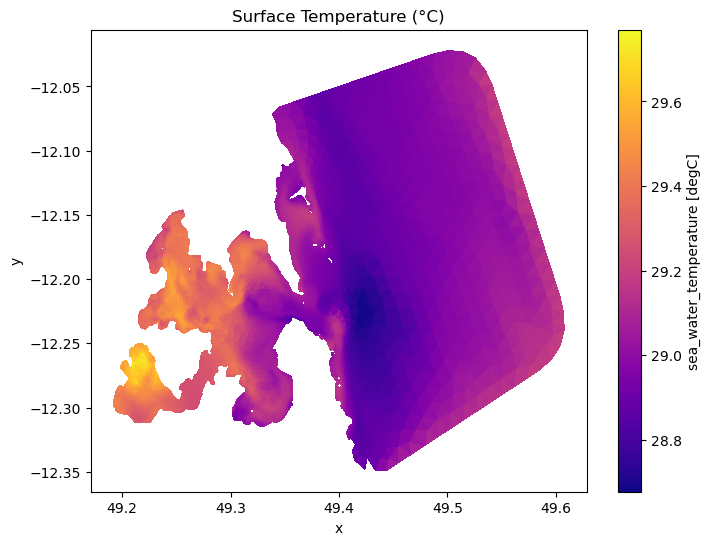

In [21]:
# Surface temperature — demonstrates xarray ops preserve the UGRID grid
temp_surf = uds['temperature'].isel(level=0, time=-1).load()

temp_surf.ugrid.plot(cmap='plasma', figsize=(8, 6))
plt.title('Surface Temperature (°C)')
plt.show()

In [22]:
type(temp_surf)

xugrid.core.wrap.UgridDataArray

In [23]:
import hvplot.xugrid  #  Experimental -- OpenScienceComputing fork of hvplot

In [24]:
temp_surf.hvplot.trimesh(rasterize=True, geo=True, cmap='plasma', tiles='OSM')

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [x,y]   (x_y z)

### 2.6 Time series at a point

`xugrid` can select the nearest mesh node directly — no external indexer needed.

In [25]:
target_lon, target_lat = 49.29, -12.22   # Antsiranana Bay

# xugrid knows the mesh topology — select nearest node directly
ts = uds['temperature'].isel(level=0).ugrid.sel(
    x=target_lon, y=target_lat
).load()

ts.hvplot(x='time', grid=True, title='Surface Temperature at Antsiranana Bay', ylabel='°C')

:Curve   [time]   (temperature)

### 2.6 xarray operations preserve the grid

Standard xarray reductions work on `UgridDataArray` — the UGRID topology is carried along automatically.

Result type: UgridDataArray


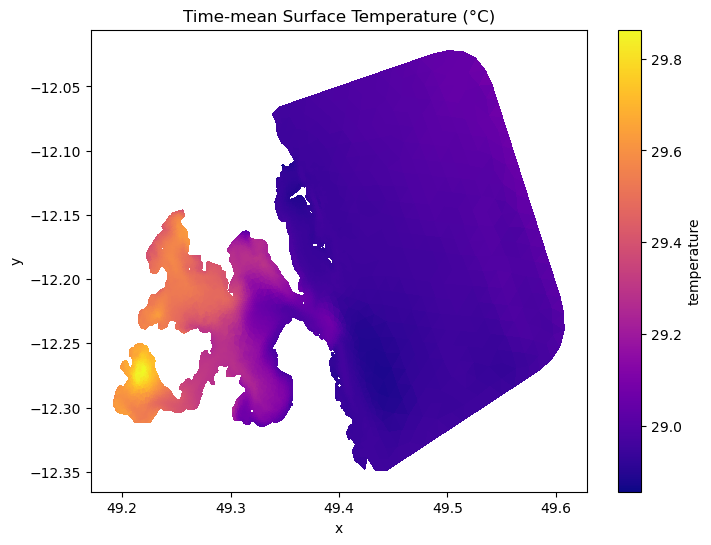

In [26]:
# Time-mean surface temperature
temp_mean = uds['temperature'].isel(level=0).mean('time').load()

print(f"Result type: {type(temp_mean).__name__}")

temp_mean.ugrid.plot(cmap='plasma', figsize=(8, 6))
plt.title('Time-mean Surface Temperature (°C)')
plt.show()

### 2.7 Spatial clipping

Full mesh:    14,602 faces
Clipped mesh: 2,529 faces


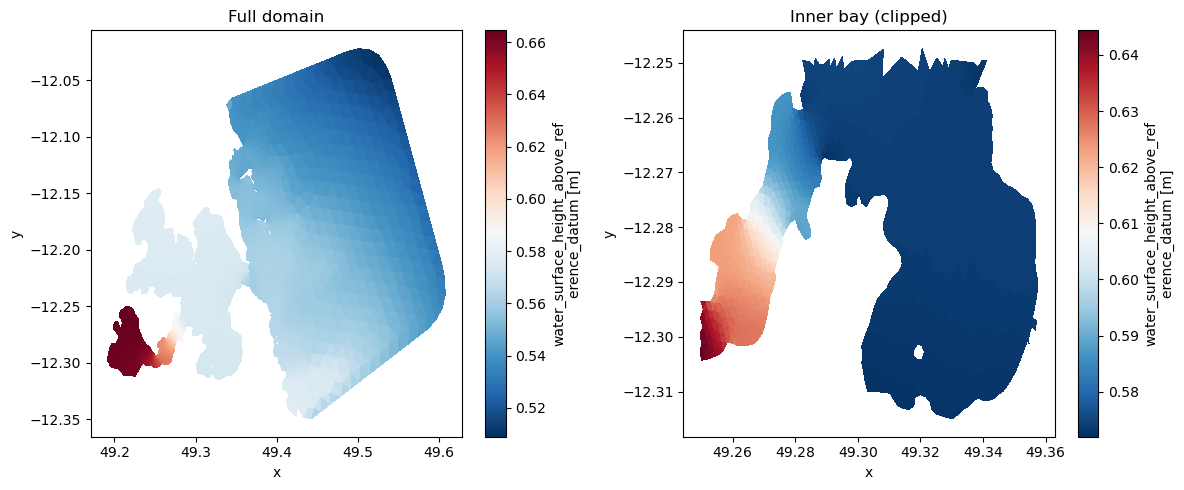

In [27]:
# Clip to inner bay — topology is automatically subsetted
uds_bay = uds.ugrid.clip_box(xmin=49.25, ymin=-12.40, xmax=49.375, ymax=-12.25)

print(f"Full mesh:    {uds.ugrid.grid.n_face:,} faces")
print(f"Clipped mesh: {uds_bay.ugrid.grid.n_face:,} faces")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
uds['water_level'].isel(time=-1).load().ugrid.plot(ax=axes[0], cmap='RdBu_r')
axes[0].set_title('Full domain')
uds_bay['water_level'].isel(time=-1).load().ugrid.plot(ax=axes[1], cmap='RdBu_r')
axes[1].set_title('Inner bay (clipped)')
plt.tight_layout()
plt.show()

### 2.8 Regridding to a structured grid

A common workflow: **native unstructured mesh → regular lat/lon grid** for post-processing or comparison with satellite data.

SHYFEM stores data at **nodes** (vertices). xugrid’s  works on face-centered data, so we first use  to average the three node values of each triangle onto the face centroid.

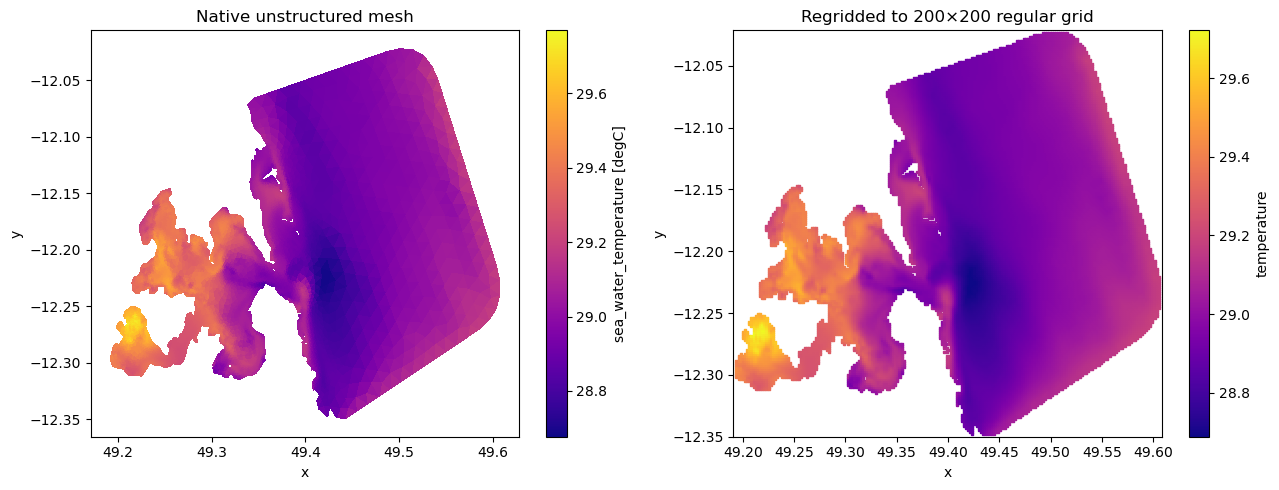

In [28]:
# Build a regular target grid covering the domain
lon_range = np.linspace(float(ds.longitude.min()), float(ds.longitude.max()), 200)
lat_range = np.linspace(float(ds.latitude.min()), float(ds.latitude.max()), 200)

da_structured = xr.DataArray(
    np.zeros((len(lat_range), len(lon_range))),
    dims=["latitude", "longitude"],
    coords={"longitude": lon_range, "latitude": lat_range},
)
target_grid = xu.Ugrid2d.from_structured(da_structured)

# Convert node-centered data to face-centered (mean of 3 nodes per triangle)
temp_face = uds["temperature"].isel(level=0, time=-1).ugrid.to_face().mean("nmax").load()

# Regrid to regular grid using BarycentricInterpolator
regridder = xu.BarycentricInterpolator(source=uds, target=target_grid)
temp_regridded = regridder.regrid(temp_face)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
uds["temperature"].isel(level=0, time=-1).load().ugrid.plot(ax=axes[0], cmap="plasma")
axes[0].set_title("Native unstructured mesh")
temp_regridded.ugrid.plot(ax=axes[1], cmap="plasma")
axes[1].set_title("Regridded to 200×200 regular grid")
plt.tight_layout()
plt.show()

### 2.9 Export back to NetCDF with full UGRID attributes

In [29]:
# Convert back to a plain xr.Dataset with all UGRID CF attributes written out
ds_out = uds.ugrid.to_dataset()

# Verify the UGRID attributes are now present
print("mesh_topology cf_role:          ", ds_out['topology'].attrs.get('cf_role'))
print("face_node_connectivity pointer: ", ds_out['topology'].attrs.get('face_node_connectivity'))
print("node_coordinates pointer:       ", ds_out['topology'].attrs.get('node_coordinates'))

mesh_topology cf_role:           mesh_topology
face_node_connectivity pointer:  element_index
node_coordinates pointer:        longitude latitude


---
## Summary

### CF Conventions + cf_xarray

| Task | Without CF | With cf_xarray |
|---|---|---|
| Get longitude | `ds['longitude']` (if you know the name) | `ds.cf['longitude']` |
| Get temperature | `ds['temperature']` | `ds.cf['sea_water_temperature']` |
| Select by time | `ds.sel(time='2021-04')` | `ds.cf.sel(T='2021-04')` |
| Select depth | `ds.sel(level=10)` | `ds.cf.sel(Z=10)` |
| Works across models | No — names vary | Yes — `standard_name` is universal |

### UGRID Conventions + xugrid

| Task | Without xugrid | With xugrid |
|---|---|---|
| Open UGRID file | `xr.open_dataset()` (raw arrays) | `xu.open_dataset()` (topology-aware) |
| Plot on native mesh | manual triangulation + datashader | `.ugrid.plot()` |
| Spatial clip | manual index math | `.ugrid.clip_box()` |
| Regrid to structured | scipy + manual | `xu.BarycentricInterpolator` |
| xarray time ops | lose grid context | grid preserved automatically |

### Resources

- [CF Conventions](https://cfconventions.org/) and [Standard Names table](https://cfconventions.org/standard-names.html)
- [cf_xarray docs](https://cf-xarray.readthedocs.io/)
- [UGRID Conventions](https://ugrid-conventions.github.io/ugrid-conventions/)
- [xugrid docs](https://deltares.github.io/xugrid/) and [examples gallery](https://deltares.github.io/xugrid/examples/)